In [1]:
import os, random, copy
import numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình đường dẫn và tham số
DATA_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"
train_csv = os.path.join(DATA_DIR, "train.csv")
val_csv   = os.path.join(DATA_DIR, "validation.csv")
test_csv  = os.path.join(DATA_DIR, "test.csv")

BATCH_SIZE = 32
EPOCHS = 30
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print("DEVICE:", DEVICE)

DEVICE: cuda


In [2]:
class EuroSATDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        if self.df.columns[0] == "Unnamed: 0":
            self.df = self.df.drop(columns=self.df.columns[0])
            
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(self.df["ClassName"].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx]["Filename"])
        label = self.class_to_idx[self.df.iloc[idx]["ClassName"]]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        return image, label

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [3]:
train_dataset = EuroSATDataset(train_csv, DATA_DIR, train_transform)
val_dataset   = EuroSATDataset(val_csv,   DATA_DIR, val_transform)
test_dataset  = EuroSATDataset(test_csv,  DATA_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_dataset.classes)
print(f"Số lượng classes: {num_classes}")

Số lượng classes: 10


In [4]:
class CustomEuroSATCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomEuroSATCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        # Block 2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        # Block 3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        # Block 4
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        # Fully Connected Head
        self.fc1 = nn.Linear(128 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))
        
        # Dàn phẳng tensor 3D thành 1D
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def create_model():
    model = CustomEuroSATCNN(num_classes=num_classes)
    return model.to(DEVICE)

In [5]:
def plot_history(history, title="Training Curve"):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def train_model(optimizer_name, lr):
    model = create_model()
    criterion = nn.CrossEntropyLoss()

    # Tối ưu hóa TOÀN BỘ MẠNG
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)

    best_val_acc = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience = 5
    no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(EPOCHS):
        # TRAIN PHASE
        model.train()
        running_loss = 0
        train_preds, train_labels = [], []
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, 1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)

        # VALIDATION PHASE
        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                preds = torch.argmax(outputs, 1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())
                
        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)

        print(f"{optimizer_name} | LR={lr} | Epoch {epoch+1} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping triggered!")
                break

    model.load_state_dict(best_model_wts)
    return model, best_val_acc, history


def evaluate_model(model):
    model.eval()
    test_preds, test_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = torch.argmax(outputs, 1).cpu().numpy()
            test_preds.extend(preds)
            test_labels.extend(labels.numpy())

    acc = accuracy_score(test_labels, test_preds)
    precision = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
    recall = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
    f1_macro = f1_score(test_labels, test_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(test_labels, test_preds, average='weighted', zero_division=0)

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(test_labels, test_preds, zero_division=0))

    print("\n===== CONFUSION MATRIX =====")
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1_macro": f1_macro,
        "F1_weighted": f1_weighted
    }


--- Bắt đầu train với Adam, LR = 0.001 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [03:44<00:00,  2.64it/s]


Adam | LR=0.001 | Epoch 1 | Train Acc=0.5538 | Val Acc=0.7443


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:26<00:00,  6.83it/s]


Adam | LR=0.001 | Epoch 2 | Train Acc=0.7165 | Val Acc=0.7878


...

Adam | LR=0.001 | Epoch 26 | Train Acc=0.9671 | Val Acc=0.9469


Epoch 27/30 [Train]: 100%|██████████| 591/591 [01:36<00:00,  6.13it/s]


Adam | LR=0.001 | Epoch 27 | Train Acc=0.9685 | Val Acc=0.9472


Epoch 28/30 [Train]: 100%|██████████| 591/591 [01:27<00:00,  6.72it/s]


Adam | LR=0.001 | Epoch 28 | Train Acc=0.9685 | Val Acc=0.9459
Early stopping triggered!


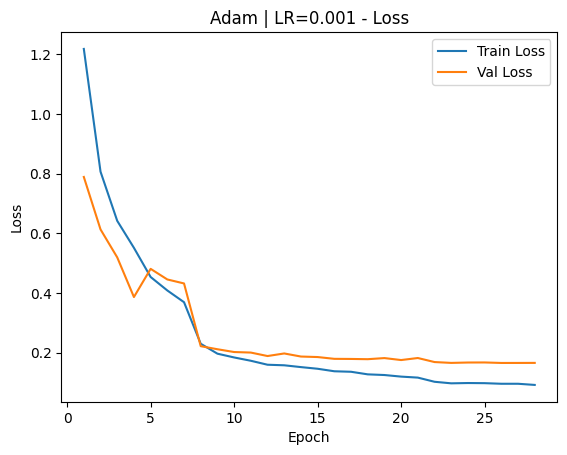

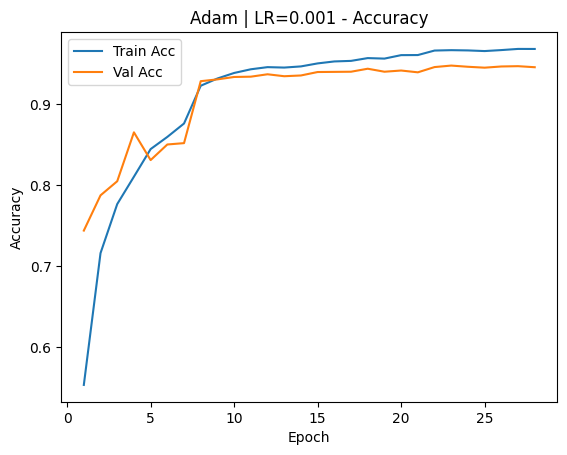


--- Bắt đầu train với Adam, LR = 0.0001 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [01:24<00:00,  6.98it/s]


Adam | LR=0.0001 | Epoch 1 | Train Acc=0.4587 | Val Acc=0.6413


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:13<00:00,  7.99it/s]


Adam | LR=0.0001 | Epoch 2 | Train Acc=0.6434 | Val Acc=0.7030


...

Adam | LR=0.0001 | Epoch 28 | Train Acc=0.8969 | Val Acc=0.8980


Epoch 29/30 [Train]: 100%|██████████| 591/591 [01:30<00:00,  6.54it/s]


Adam | LR=0.0001 | Epoch 29 | Train Acc=0.8962 | Val Acc=0.8978


Epoch 30/30 [Train]: 100%|██████████| 591/591 [01:37<00:00,  6.04it/s]


Adam | LR=0.0001 | Epoch 30 | Train Acc=0.8949 | Val Acc=0.8956


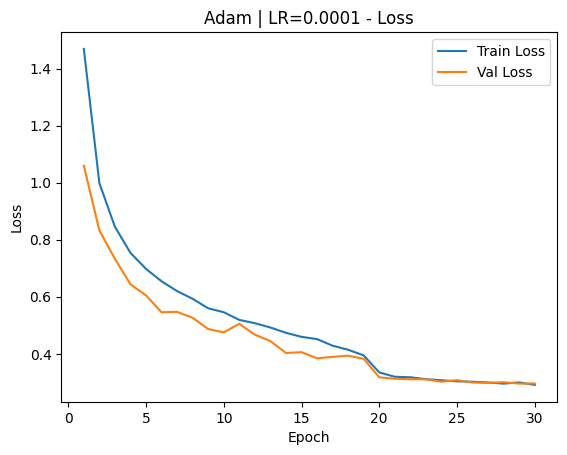

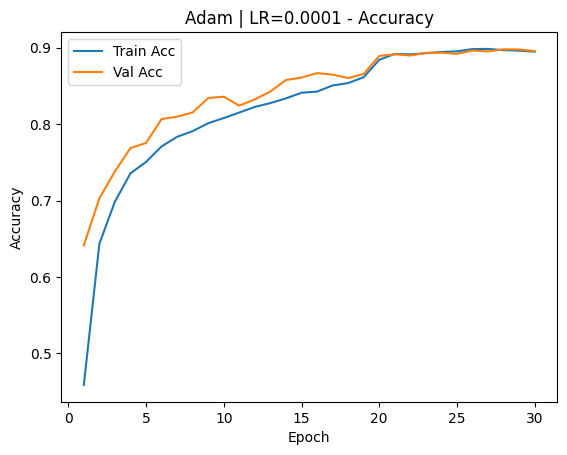


--- Bắt đầu train với Adam, LR = 1e-05 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [01:35<00:00,  6.22it/s]


Adam | LR=1e-05 | Epoch 1 | Train Acc=0.3081 | Val Acc=0.3778


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:14<00:00,  7.97it/s]


Adam | LR=1e-05 | Epoch 2 | Train Acc=0.4274 | Val Acc=0.4743


...

Adam | LR=1e-05 | Epoch 28 | Train Acc=0.7354 | Val Acc=0.7502


Epoch 29/30 [Train]: 100%|██████████| 591/591 [01:11<00:00,  8.31it/s]


Adam | LR=1e-05 | Epoch 29 | Train Acc=0.7392 | Val Acc=0.7472


Epoch 30/30 [Train]: 100%|██████████| 591/591 [01:12<00:00,  8.17it/s]


Adam | LR=1e-05 | Epoch 30 | Train Acc=0.7422 | Val Acc=0.7578


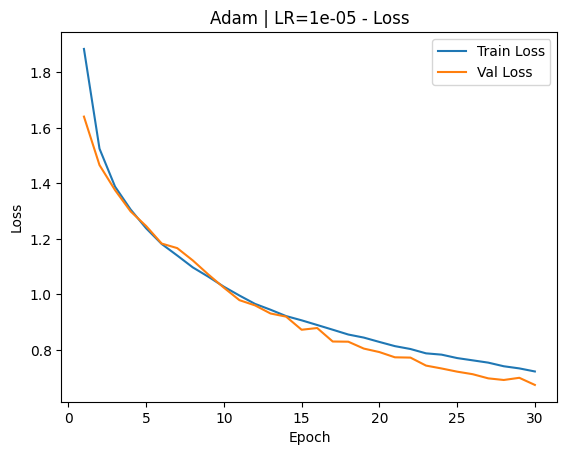

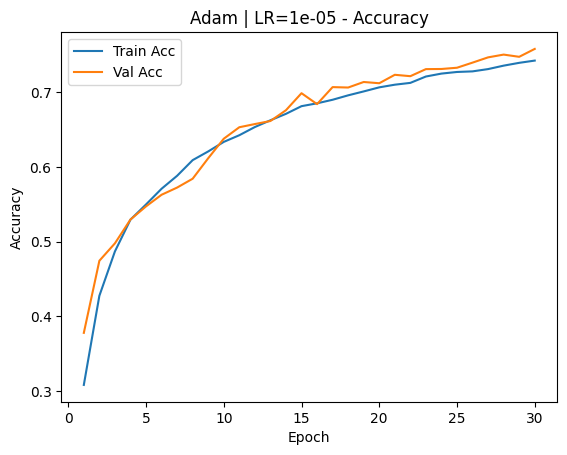


>>> BEST Adam: LR=0.001 | Val Acc=0.9480


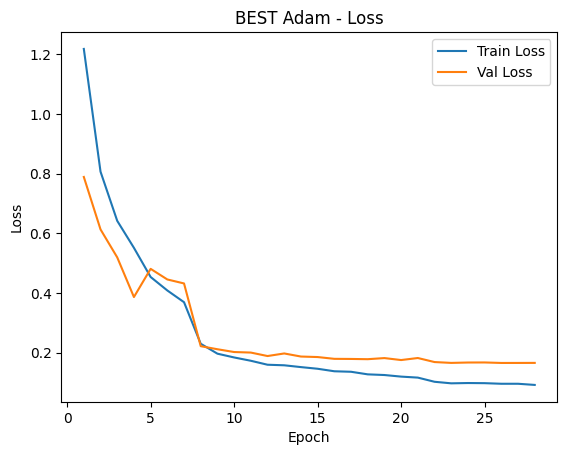

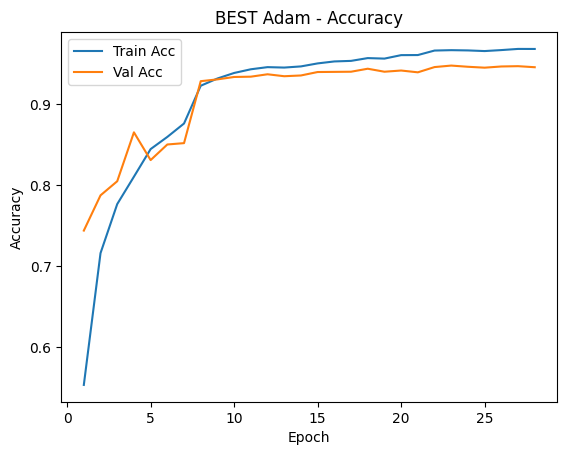


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       300
           1       0.97      1.00      0.99       300
           2       0.93      0.93      0.93       300
           3       0.92      0.90      0.91       250
           4       0.98      0.96      0.97       250
           5       0.92      0.91      0.91       200
           6       0.91      0.91      0.91       250
           7       0.98      0.99      0.99       300
           8       0.88      0.89      0.89       250
           9       0.99      0.97      0.98       300

    accuracy                           0.94      2700
   macro avg       0.94      0.94      0.94      2700
weighted avg       0.94      0.94      0.94      2700


===== CONFUSION MATRIX =====


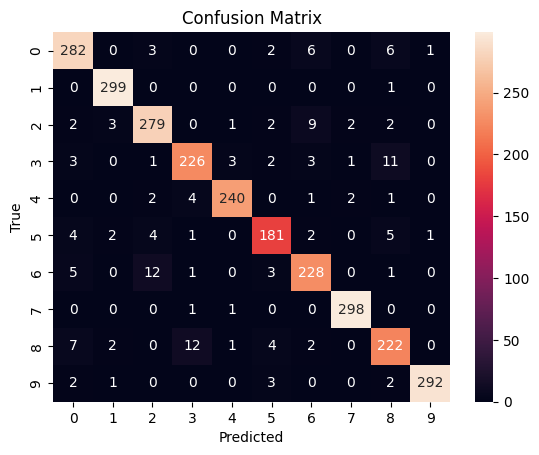


--- Bắt đầu train với AdamW, LR = 0.001 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [01:12<00:00,  8.17it/s]


AdamW | LR=0.001 | Epoch 1 | Train Acc=0.5351 | Val Acc=0.7017


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:12<00:00,  8.16it/s]


AdamW | LR=0.001 | Epoch 2 | Train Acc=0.7170 | Val Acc=0.7846


...

AdamW | LR=0.001 | Epoch 28 | Train Acc=0.9820 | Val Acc=0.9513


Epoch 29/30 [Train]: 100%|██████████| 591/591 [02:38<00:00,  3.72it/s]


AdamW | LR=0.001 | Epoch 29 | Train Acc=0.9830 | Val Acc=0.9533


Epoch 30/30 [Train]: 100%|██████████| 591/591 [01:16<00:00,  7.75it/s]


AdamW | LR=0.001 | Epoch 30 | Train Acc=0.9847 | Val Acc=0.9526


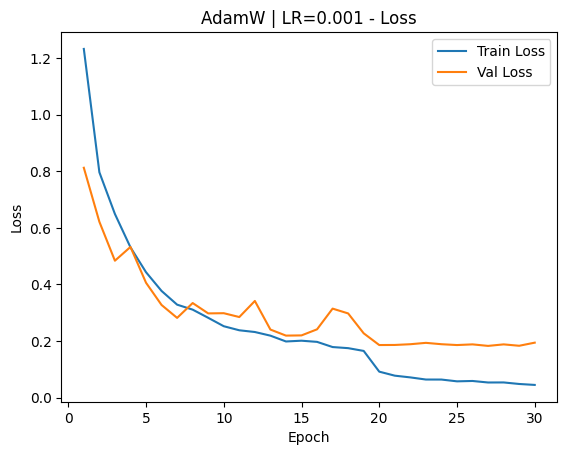

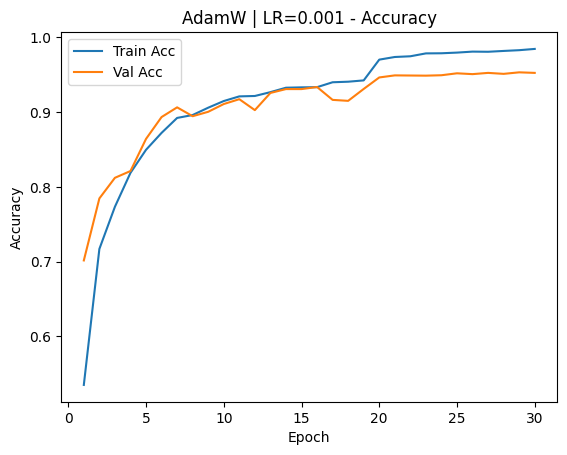


--- Bắt đầu train với AdamW, LR = 0.0001 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [01:15<00:00,  7.87it/s]


AdamW | LR=0.0001 | Epoch 1 | Train Acc=0.4829 | Val Acc=0.6200


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:16<00:00,  7.77it/s]


AdamW | LR=0.0001 | Epoch 2 | Train Acc=0.6445 | Val Acc=0.7070


...

AdamW | LR=0.0001 | Epoch 28 | Train Acc=0.8881 | Val Acc=0.8954


Epoch 29/30 [Train]: 100%|██████████| 591/591 [01:14<00:00,  7.98it/s]


AdamW | LR=0.0001 | Epoch 29 | Train Acc=0.8963 | Val Acc=0.8726


Epoch 30/30 [Train]: 100%|██████████| 591/591 [01:15<00:00,  7.80it/s]


AdamW | LR=0.0001 | Epoch 30 | Train Acc=0.9006 | Val Acc=0.8974


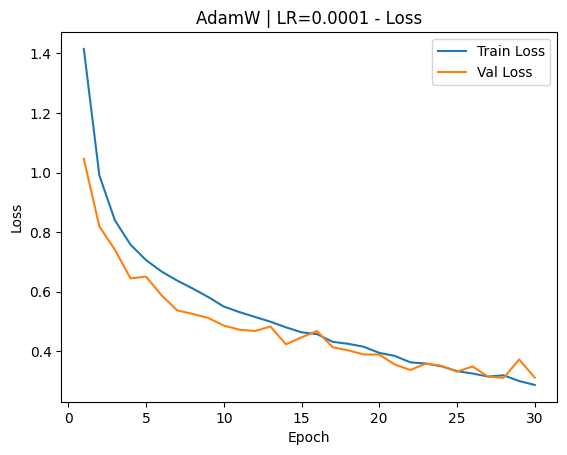

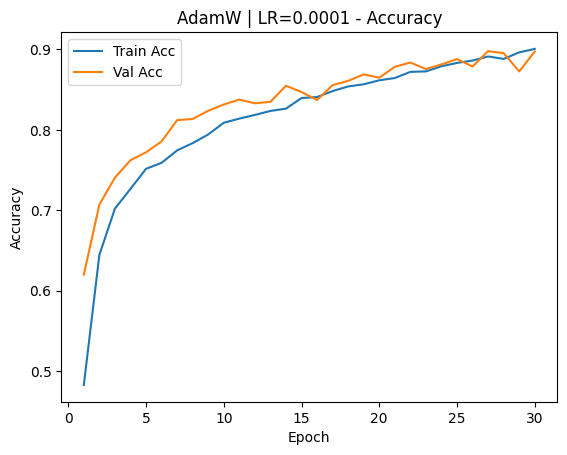


--- Bắt đầu train với AdamW, LR = 1e-05 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [01:14<00:00,  7.98it/s]


AdamW | LR=1e-05 | Epoch 1 | Train Acc=0.3081 | Val Acc=0.3713


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:13<00:00,  8.01it/s]


AdamW | LR=1e-05 | Epoch 2 | Train Acc=0.4258 | Val Acc=0.4278


...

AdamW | LR=1e-05 | Epoch 28 | Train Acc=0.7533 | Val Acc=0.7611


Epoch 29/30 [Train]: 100%|██████████| 591/591 [01:18<00:00,  7.49it/s]


AdamW | LR=1e-05 | Epoch 29 | Train Acc=0.7547 | Val Acc=0.7596


Epoch 30/30 [Train]: 100%|██████████| 591/591 [01:37<00:00,  6.04it/s]


AdamW | LR=1e-05 | Epoch 30 | Train Acc=0.7586 | Val Acc=0.7617


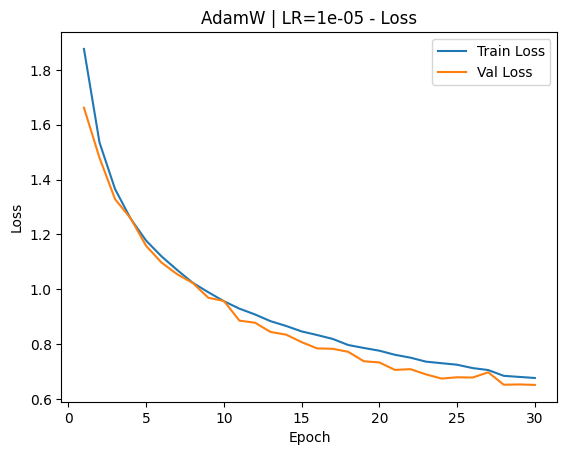

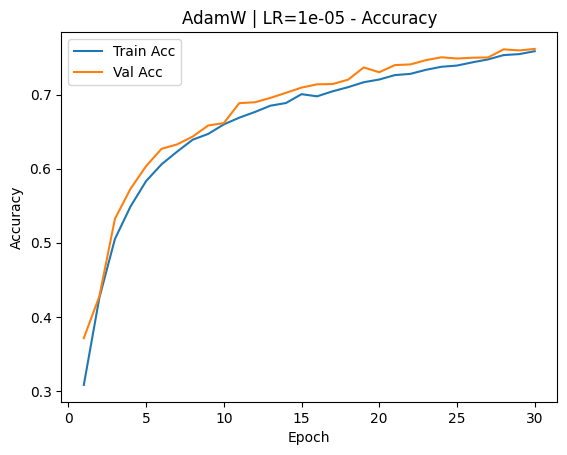


>>> BEST AdamW: LR=0.001 | Val Acc=0.9533


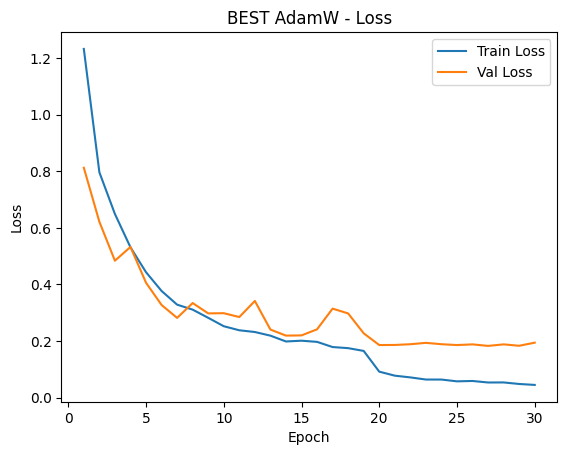

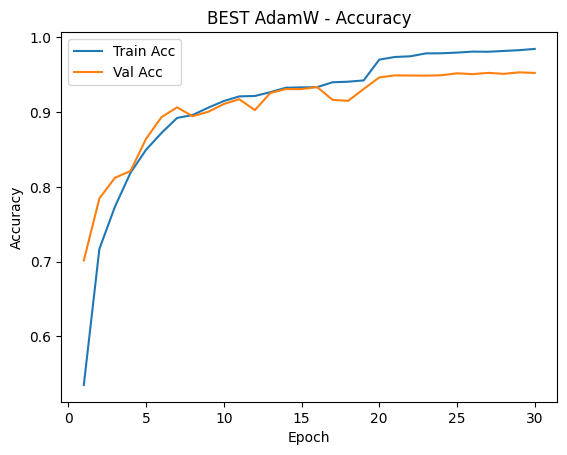


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       300
           1       0.98      0.99      0.99       300
           2       0.94      0.94      0.94       300
           3       0.94      0.95      0.95       250
           4       0.99      0.96      0.98       250
           5       0.96      0.93      0.94       200
           6       0.94      0.94      0.94       250
           7       0.98      1.00      0.99       300
           8       0.93      0.94      0.93       250
           9       1.00      0.98      0.99       300

    accuracy                           0.96      2700
   macro avg       0.96      0.96      0.96      2700
weighted avg       0.96      0.96      0.96      2700


===== CONFUSION MATRIX =====


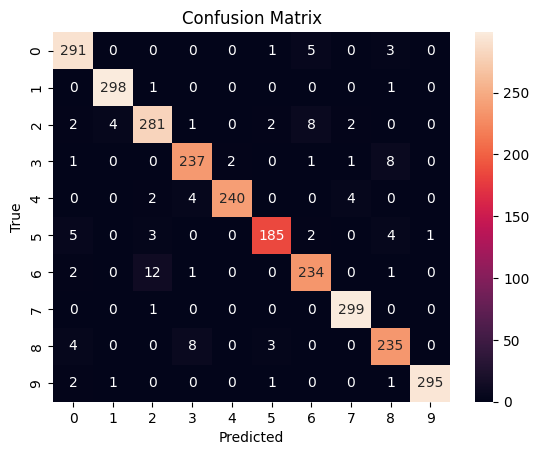


--- Bắt đầu train với SGD, LR = 0.001 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [01:21<00:00,  7.26it/s]


SGD | LR=0.001 | Epoch 1 | Train Acc=0.2803 | Val Acc=0.4580


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:21<00:00,  7.28it/s]


SGD | LR=0.001 | Epoch 2 | Train Acc=0.5023 | Val Acc=0.5300


...

SGD | LR=0.001 | Epoch 28 | Train Acc=0.9207 | Val Acc=0.9102


Epoch 29/30 [Train]: 100%|██████████| 591/591 [01:18<00:00,  7.54it/s]


SGD | LR=0.001 | Epoch 29 | Train Acc=0.9206 | Val Acc=0.9141


Epoch 30/30 [Train]: 100%|██████████| 591/591 [01:16<00:00,  7.69it/s]


SGD | LR=0.001 | Epoch 30 | Train Acc=0.9212 | Val Acc=0.9152


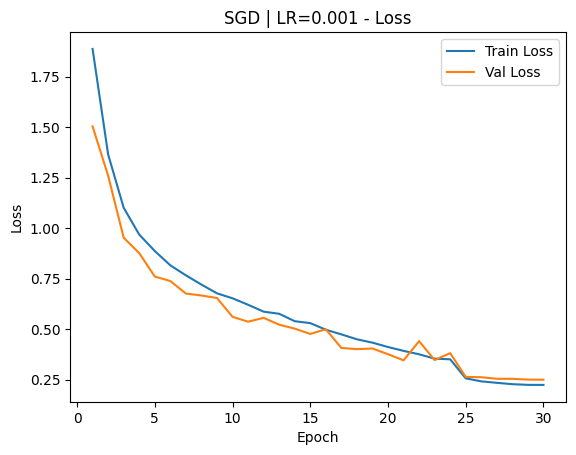

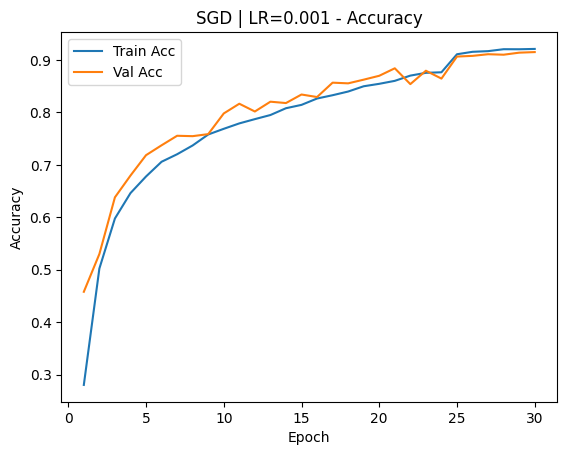


--- Bắt đầu train với SGD, LR = 0.0001 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [01:27<00:00,  6.73it/s]


SGD | LR=0.0001 | Epoch 1 | Train Acc=0.1392 | Val Acc=0.2344


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:23<00:00,  7.09it/s]


SGD | LR=0.0001 | Epoch 2 | Train Acc=0.2293 | Val Acc=0.2141


...

SGD | LR=0.0001 | Epoch 28 | Train Acc=0.6803 | Val Acc=0.6278


Epoch 29/30 [Train]: 100%|██████████| 591/591 [01:21<00:00,  7.24it/s]


SGD | LR=0.0001 | Epoch 29 | Train Acc=0.6874 | Val Acc=0.6022


Epoch 30/30 [Train]: 100%|██████████| 591/591 [01:23<00:00,  7.11it/s]


SGD | LR=0.0001 | Epoch 30 | Train Acc=0.6901 | Val Acc=0.6569


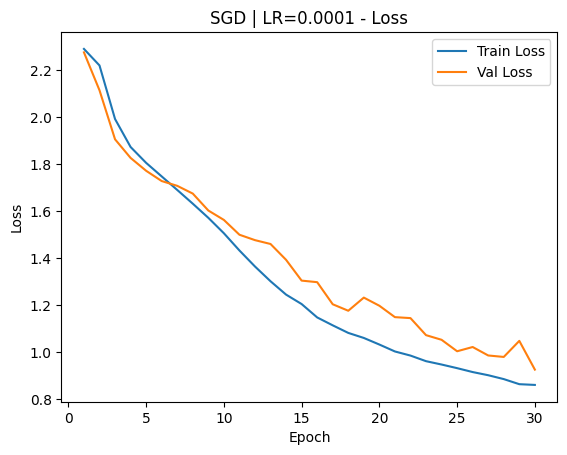

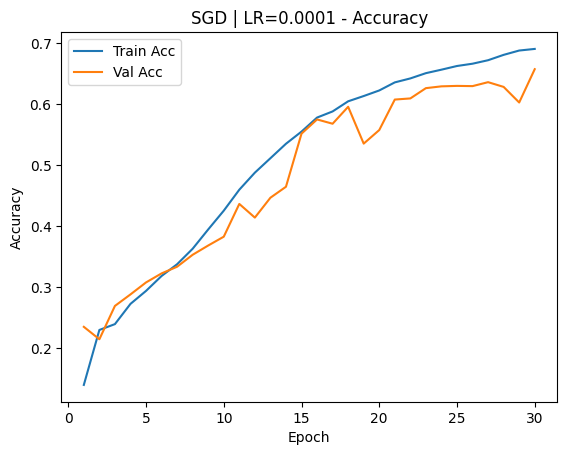


--- Bắt đầu train với SGD, LR = 1e-05 ---


Epoch 1/30 [Train]: 100%|██████████| 591/591 [01:24<00:00,  7.01it/s]


SGD | LR=1e-05 | Epoch 1 | Train Acc=0.1144 | Val Acc=0.1500


Epoch 2/30 [Train]: 100%|██████████| 591/591 [01:40<00:00,  5.86it/s]


SGD | LR=1e-05 | Epoch 2 | Train Acc=0.1342 | Val Acc=0.1581


...

SGD | LR=1e-05 | Epoch 13 | Train Acc=0.2506 | Val Acc=0.2509


Epoch 14/30 [Train]: 100%|██████████| 591/591 [01:19<00:00,  7.45it/s]


SGD | LR=1e-05 | Epoch 14 | Train Acc=0.2528 | Val Acc=0.2506


Epoch 15/30 [Train]: 100%|██████████| 591/591 [01:20<00:00,  7.31it/s]


SGD | LR=1e-05 | Epoch 15 | Train Acc=0.2520 | Val Acc=0.2498
Early stopping triggered!


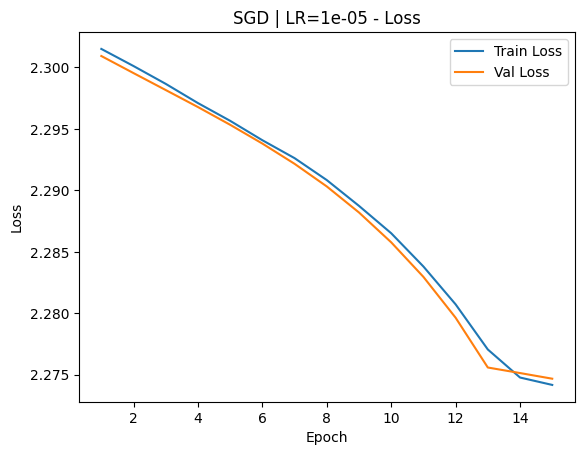

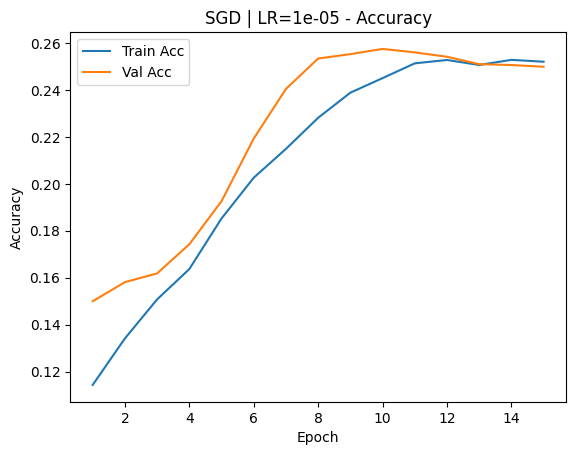


>>> BEST SGD: LR=0.001 | Val Acc=0.9152


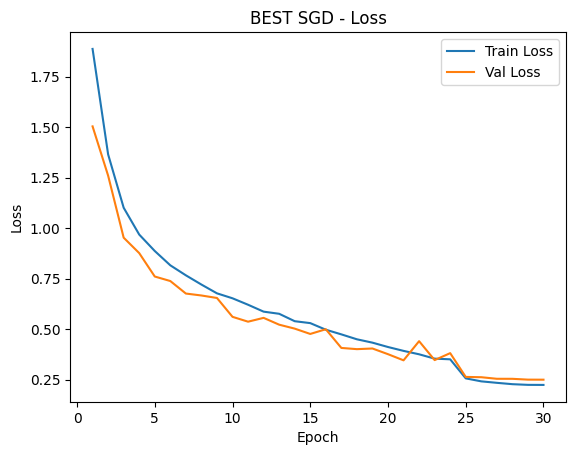

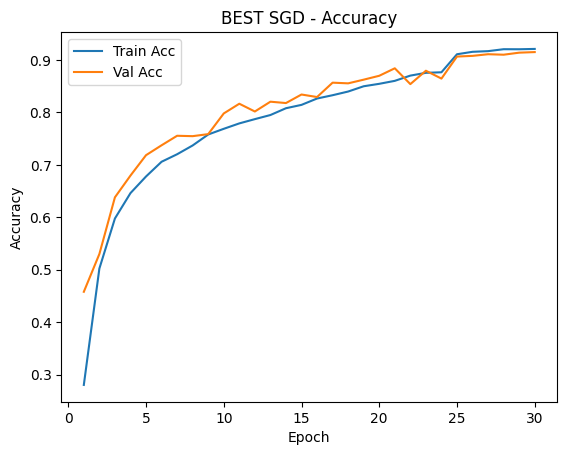


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       300
           1       0.95      0.97      0.96       300
           2       0.90      0.90      0.90       300
           3       0.88      0.85      0.86       250
           4       0.94      0.95      0.94       250
           5       0.86      0.89      0.87       200
           6       0.86      0.87      0.86       250
           7       0.96      0.99      0.98       300
           8       0.87      0.85      0.86       250
           9       0.99      0.95      0.97       300

    accuracy                           0.92      2700
   macro avg       0.91      0.91      0.91      2700
weighted avg       0.92      0.92      0.92      2700


===== CONFUSION MATRIX =====


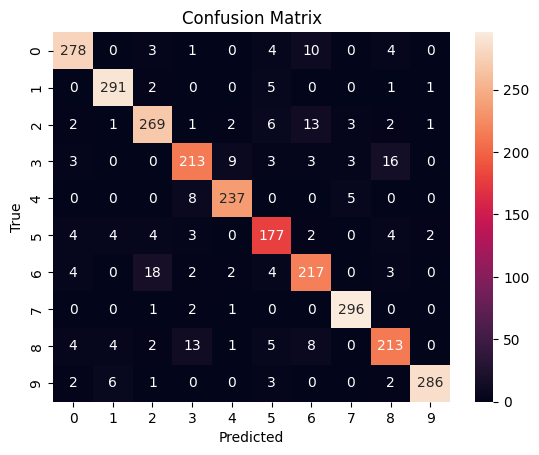

In [6]:
optimizers = ["Adam", "AdamW", "SGD"]
learning_rates = [1e-3, 1e-4, 1e-5]

results = []
global_best_acc = 0
global_best_model_weights = None
global_best_opt = None
global_best_lr = None

for opt in optimizers:
    best_acc = 0
    best_model = None
    best_lr = None
    best_history = None

    for lr in learning_rates:
        print(f"\n--- Bắt đầu train với {opt}, LR = {lr} ---")
        model, val_acc, history = train_model(opt, lr)
        plot_history(history, title=f"{opt} | LR={lr}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = model
            best_lr = lr
            best_history = history
            
        # Tìm mô hình tốt nhất toàn cục
        if val_acc > global_best_acc:
            global_best_acc = val_acc
            global_best_model_weights = copy.deepcopy(model.state_dict())
            global_best_opt = opt
            global_best_lr = lr

    print(f"\n>>> BEST {opt}: LR={best_lr} | Val Acc={best_acc:.4f}")
    plot_history(best_history, title=f"BEST {opt}")

    metrics = evaluate_model(best_model)
    metrics["Optimizer"] = opt
    metrics["Best_LR"] = best_lr
    results.append(metrics)

In [7]:
df_results = pd.DataFrame(results)

print("\n===== FINAL COMPARISON =====")
print(df_results)

best_row = df_results[
    (df_results['Optimizer'] == global_best_opt) & 
    (df_results['Best_LR'] == global_best_lr)
].iloc[0]

best_test_acc = best_row['Accuracy']

print("-" * 30)
print("Best Custom CNN model:")
print(f"Optimizer: {global_best_opt}")
print(f"Learning Rate: {global_best_lr}")
print(f"Validation Accuracy (training phase): {global_best_acc:.4f}")
print(f"Test Accuracy (final evaluation): {best_test_acc:.4f}")

# Lưu file trọng số
save_path = 'CustomCNN_EuroSAT_Best.pth'
torch.save(global_best_model_weights, save_path)

print(f"\nModel weights have been saved to: {save_path}")


===== FINAL COMPARISON =====
   Accuracy  Precision    Recall  F1_macro  F1_weighted Optimizer  Best_LR
0  0.943333   0.943378  0.943333  0.940653     0.943301      Adam    0.001
1  0.961111   0.961278  0.961111  0.959659     0.961105     AdamW    0.001
2  0.917407   0.917503  0.917407  0.913469     0.917349       SGD    0.001
------------------------------
Best Custom CNN model:
Optimizer: AdamW
Learning Rate: 0.001
Validation Accuracy (training phase): 0.9533
Test Accuracy (final evaluation): 0.9611

Model weights have been saved to: CustomCNN_EuroSAT_Best.pth
